## Leçon 7:  Différences finies avec numpy.

#### Conduction en 3 dimensions, On utilise la solution matricielle directe des équations de différences finies. 

##### Par rapport à la leçon 6, celle-ci introduit la solution directe, ce qui implique de contruire une matrice de différences finies carrée de dimension nx.ny.nz  par nx.ny.nz. Dans le cas de la conduction comme dans cet exemple, la matrice est hepta-diagonale . Les conditions aux limites sont ici très simples, Dirichlet sur toutes les faces.


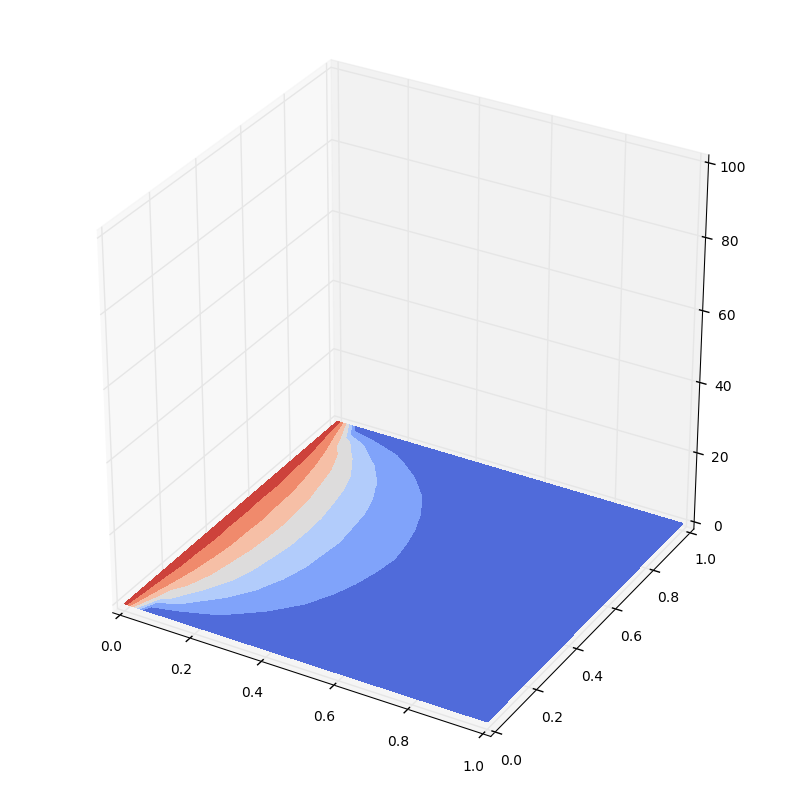

In [2]:
#
# Fonction construisant la matrice
#
def differencesFinies(NPI,NPJ,NPK,coeff,dx2m,dy2m,dz2m,A,b):
    for i in range( 0 ,NPI):
        for j in range( 0 ,NPJ) :
            for k in range( 0 ,NPK) :
                p = k   *(NPJ*NPI) +    j*(NPI)    + i
                pE= k   *(NPJ*NPI) +    j*(NPI)    + i+1
                pO= k   *(NPJ*NPI) +    j*(NPI)    + i-1 
                pN= k   *(NPJ*NPI) +(j+1)*(NPI)    + i        # Matrice de D.F. 
                pS= k   *(NPJ*NPI) +(j-1)*(NPI)    + i
                pH=(k+1)*(NPJ*NPI) +    j*(NPI)    + i
                pB=(k-1)*(NPJ*NPI) +    j*(NPI)    + i
                if   i == 0:
                    A[p,p] =1.0
                    b[p]   =100
                elif i == NII:
                    A[p,p] =1
                    b[p]   =0
                elif j == 0: 
                    A[p,p] =1.0
                    b[p]   =0
                elif j == NIJ: 
                    A[p,p] =1.0
                    b[p]   =0
                elif k == 0: 
                    A[p,p] =1.0
                    b[p]   =0
                elif k == NIK: 
                    A[p,p] =1.0
                    b[p]   =0
                else:
                    A[p,p]  =-coeff
                    A[p,pE] = dx2m 
                    A[p,pO] = dx2m
                    A[p,pN] = dy2m
                    A[p,pS] = dy2m
                    A[p,pB] = dz2m
                    A[p,pH] = dz2m                
                    b[p]    = 0
    return A,b
#
# Début du code
#
from IPython.display import *
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
from matplotlib import cm
%matplotlib inline
from numpy.linalg import solve
NII     = 16        # nombre d'intervalles direction x
NIJ     = 14        # nombre d'intervalles direction y
NIK     = 15        # nombre d'intervalles direction z
NPI     =NII+1      # nombre de points direction x
NPJ     =NIJ+1      # nombre de points direction y
NPK     =NIK+1      # nombre de points direction z

ouest = 0.0         # sera repéré dans la matrice de différences finies par pO
est   = 1.0         # sera repéré dans la matrice de différences finies par pE
sud   = 0.0         #   etc...
nord  = 1.0
haut  = 1.0
bas   = 0.0

x     = np.linspace(ouest , est  ,NPI )
y     = np.linspace( sud  , nord ,NPJ )
z     = np.linspace( bas  , haut ,NPK )
dx     = x[1]-x[0]
dy     = y[1]-y[0]
dz     = z[1]-z[0]
dx2m  = 1.0/dx**2
dy2m  = 1.0/dy**2
dz2m  = 1.0/dz**2
coeff = 2.0*(dx2m+dy2m+dz2m)
Y,X   = np.meshgrid(y,x)
total = NPI*NPJ*NPK
#
# Initialisations
# 
A     = np.zeros((total,total))
b     = np.zeros(total)
#
# Construire la matrice de D.F.
#
A,b   = differencesFinies(NPI,NPJ,NPK,coeff,dx2m,dy2m,dz2m,A,b)
t=solve(A, b )
#
#   On trace le contour en k=4
#
T=np.arange(total).reshape(NPI,NPJ,NPK)
ijk=0
for k in range(0,NPK):
    for j in range(0,NPJ):
        for i in range(0,NPI):
            T[i,j,k]=t[ijk]
            ijk=ijk+1
pos=4
ZZ=T[:,:,pos]
fig=plt.figure(pos,figsize=(10,10))  
ax = fig.gca(projection='3d')
#surf = ax.plot_surface(X, Y, ZZ, rstride=1, cstride=1, cmap=cm.jet,linewidth=0, antialiased=True)
surf = ax.contourf(X, Y, ZZ, zdir='z', offset=0, cmap=cm.coolwarm)
plt.show()